## Read the Data

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import statsmodels.api as sm
import pymc as pm
import arviz as az
from matplotlib import rcParams
import seaborn as sb
import sys
sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Engram_2P/visualization'])
from plotting import despine
plt.style.use('paper_style.mplstyle')


In [2]:
data=pd.read_csv('/Users/amonast/Documents/GitHub/Amy_Reviews/data/rates_total_weighted_5std_all.csv',index_col=0)
data['Session']=data['Session'].map({'Baseline': 'D0', 'Post': 'D4'})

#data = data.loc[(data['Baseline']!=-1) & (data['Post']!=-1)]
rest_data = pd.read_csv('/Users/amonast/Documents/GitHub/Amy_Reviews/data/rates_rest_weighted_5std_all.csv',index_col=0)
rest_data['Session']=rest_data['Session'].map({'Baseline': 'D0', 'Post': 'D4'})

run_data=pd.read_csv('/Users/amonast/Documents/GitHub/Amy_Reviews/data/rates_run_weighted_5std_all.csv',index_col=0)
run_data['Session']=run_data['Session'].map({'Baseline': 'D0', 'Post': 'D4'})

In [3]:
data.Animal.unique().shape

(16,)

In [6]:
data.loc[(data['Session']=='D0')&(data['Group']=='FC')].shape[0]

2384

In [8]:
data.loc[(data['Session']=='D0')&(data['Group']=='HC')].shape[0]

2379

In [4]:
rest_data.loc[(rest_data['Session']=='D0')&(rest_data['Group']=='FC')].shape[0]

2183

In [5]:
rest_data.loc[(rest_data['Session']=='D0')&(rest_data['Group']=='HC')].shape[0]

1894

In [5]:
for ani in data['Animal'].unique():
    print(data[data['Animal'] == ani]['Group'].iloc[0])

FC
FC
FC
HC
FC
HC
HC
FC
FC
HC
HC
FC
HC
FC
HC
HC


#### set labels and color scheme and plot settings

In [5]:
label_map={'9972R':'FC1','992N':'FC2','989N':'FC3',
           '149L':'FC4','146R':'FC5','160R':'FC6','492N':'FC7','493R':'FC8',
           '589L':'HC1','992L':'HC2','994R':'HC3',
           '034R':'HC4','217N':'HC5','218L':'HC6','217R':'HC7','1912L':'HC8'}

In [6]:
# rename columns
data.rename(columns={"Event Rate": "Event_Rate"}, inplace=True)
data['logEventRate']=np.log(data['Event_Rate'])

rest_data.rename(columns={"Event Rate": "Event_Rate"}, inplace=True)
run_data.rename(columns={"Event Rate": "Event_Rate"}, inplace=True)

data_matrix = data[['Event_Rate', 'Population', 'Animal', 'Session', 'Group']]
data_matrix = data_matrix[data_matrix['Session'] == "Baseline"]

# treat the population as a categorical variable where tagged = 1 and non-tagged = 0
data_matrix['Population'] = data_matrix['Population'].astype('category')
data_matrix['Population'] = data_matrix['Population'].cat.codes

# run matrix
run_data_matrix = run_data[['Event_Rate', 'Population', 'Animal', 'Session', 'Group']]
run_data_matrix = run_data_matrix[run_data_matrix['Session'] == "Baseline"].dropna()

# treat the population as a categorical variable where tagged = 1 and non-tagged = 0
run_data_matrix['Population'] = run_data_matrix['Population'].astype('category')
run_data_matrix['Population'] = run_data_matrix['Population'].cat.codes

# rest_matrix
rest_data_matrix = rest_data[['Event_Rate', 'Population', 'Animal', 'Session', 'Group']]
rest_data_matrix = rest_data_matrix[rest_data_matrix['Session'] == "Baseline"].dropna()

# treat the population as a categorical variable where tagged = 1 and non-tagged = 0
rest_data_matrix['Population'] = rest_data_matrix['Population'].astype('category')
rest_data_matrix['Population'] = rest_data_matrix['Population'].cat.codes

combined_data_matrix = run_data_matrix.copy()
combined_data_matrix.rename(columns={"Event_Rate": "Event_Rate_Run"}, inplace=True)

combined_data_matrix['Event_Rate_Rest'] = rest_data_matrix['Event_Rate']

# Supplementary Figure 4A

In [7]:
# seperate by cell type
engram_cells = data[data['Population'] == 'Tagged']
non_engram_cells = data[data['Population'] == 'Non-Tagged']

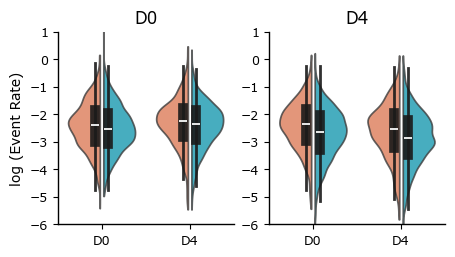

In [8]:
hue_order = ['Tagged','Non-Tagged']
order = ['FC','HC']
fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(5,2.5))
sb.violinplot(data=data.loc[data['Group']=='FC'],y='logEventRate',x='Session',hue='Population',dodge=.5,width=.8,bw_adjust=.9,cut=0,
              gap=0.1,density_norm='width',split=True,hue_order=hue_order,alpha=0.8,inner='box',palette=['#F37243','#00ABC8'],ax=ax[0],inner_kws=dict(box_width=7, whis_width=2, color="0.1",alpha=0.9))

sb.violinplot(data=data.loc[data['Group']=='HC'],y='logEventRate',x='Session',hue='Population',dodge=.5,width=.8,bw_adjust=.9,cut=0,
              gap=0.1,density_norm='width',split=True,hue_order=hue_order,alpha=0.8,inner='box',palette=['#F37243','#00ABC8'],ax=ax[1],inner_kws=dict(box_width=7, whis_width=2, color="0.1",alpha=0.9))
plt.setp(ax,ylim=(-6,1))
sb.despine()
titles=['D0','D4']
for a,axis in enumerate(ax):
    #despine(axis)
    axis.legend().remove()
    axis.set_title(titles[a],size=12)
ax[0].set_ylabel('log (Event Rate)')
ax[1].set_ylabel('')
ax[0].set_xlabel('')
ax[1].set_xlabel('')

plt.savefig(f"SuppFig4A_violinplots_cells.svg",transparent=True)

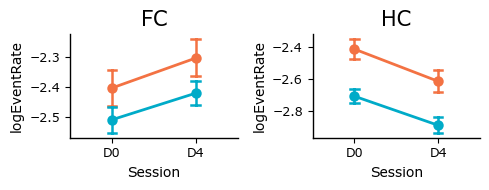

In [10]:
hue_order = ['Tagged','Non-Tagged']
fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(5,2))
sb.pointplot(data=data.loc[(data['Group']=='FC')],
             y='logEventRate',hue='Population',
             x='Session',ax=ax[0],
             hue_order=hue_order,
             errorbar='ci',
             palette=['#F37243','#00ABC8'],
            capsize=0.1,
             markers='o',
             linestyles='-',
             dodge=0,
             markersize=6,
             linewidth=2,
             err_kws=dict(lw=1.8))
ax[0].set_title('FC')
sb.pointplot(data=data.loc[(data['Group']=='HC')],y='logEventRate',
             hue='Population',x='Session',
             ax=ax[1],
             hue_order=hue_order,
             errorbar='ci',
             palette=['#F37243','#00ABC8'],
             capsize=0.1,
             markers='o',
             linestyles='-',
             dodge=0,
             markersize=6,
             linewidth=2,
             err_kws=dict(lw=1.8))
ax[1].set_title('HC')
ax[0].legend_.remove()
ax[1].legend_.remove()

sb.despine()
plt.tight_layout()
plt.savefig('SuppFig4A_pointplot_total_95ci.svg',transparent=True)

## Figure 3A

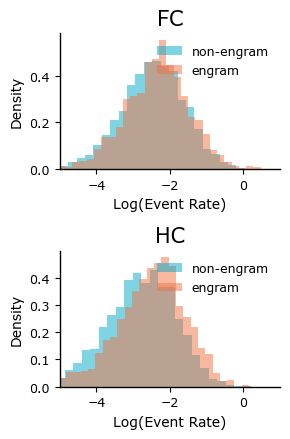

In [ ]:
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(3,4.5))
palette=['#F37243','#00ABC8']
ax[0].hist(np.log(non_engram_cells['Event_Rate'].loc[non_engram_cells['Group']=='FC']), bins=30, label='non-engram', density=True, alpha=0.5, edgecolor='none',color=palette[1])
ax[0].hist(np.log(engram_cells['Event_Rate'].loc[engram_cells['Group']=='FC']), bins=30, label='engram', density=True, alpha=0.5, edgecolor='none',color=palette[0])

ax[0].set_xlabel('Log(Event Rate)')
ax[0].set_ylabel('Density')
ax[0].set_title('FC')
ax[0].legend(frameon=False)

ax[1].hist(np.log(non_engram_cells['Event_Rate'].loc[non_engram_cells['Group']=='HC']), bins=30, label='non-engram', density=True, alpha=0.5, edgecolor='none',color=palette[1])
ax[1].hist(np.log(engram_cells['Event_Rate'].loc[engram_cells['Group']=='HC']), bins=30, label='engram', density=True, alpha=0.5, edgecolor='none',color=palette[0])

ax[1].set_xlabel('Log(Event Rate)')
ax[1].set_ylabel('Density')
ax[1].set_title('HC')
ax[1].legend(frameon=False)

plt.tight_layout()
plt.setp(ax, xlim=[-5,1])
for axis in ax.flatten():
    despine(axis)
plt.savefig(f"Fig3A_Histogram_rates_allcells_groups_log.svg",transparent=True,dpi=50)

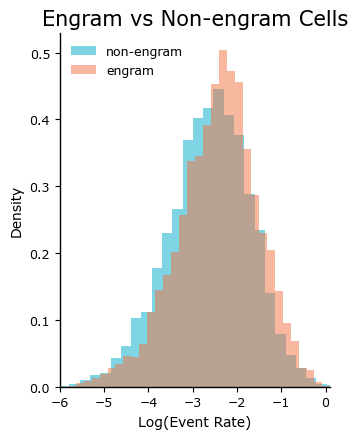

In [ ]:
fig, ax = plt.subplots(figsize=(3.5,4.5))
palette=['#F37243','#00ABC8']
ax.hist(np.log(non_engram_cells['Event_Rate']), bins=35, label='non-engram', density=True, alpha=0.5, edgecolor='none',color=palette[1])
ax.hist(np.log(engram_cells['Event_Rate']), bins=35, label='engram', density=True, alpha=0.5, edgecolor='none',color=palette[0])

ax.set_xlabel('Log(Event Rate)')
ax.set_ylabel('Density')
ax.set_title('Engram vs Non-engram Cells')
ax.legend(frameon=False)
plt.tight_layout()
plt.xlim([-6,.1])
despine(ax)
plt.savefig(f"Histogram_rates_allcells_allmice_log.svg",transparent=True,dpi=50)

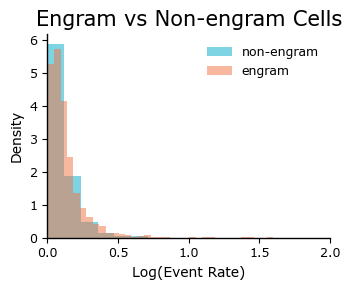

In [ ]:
fig, ax = plt.subplots(figsize=(3.5,3))
palette=['#F37243','#00ABC8']
ax.hist(non_engram_cells['Event_Rate'], bins=35, label='non-engram', density=True, alpha=0.5, edgecolor='none',color=palette[1])
ax.hist(engram_cells['Event_Rate'], bins=35, label='engram', density=True, alpha=0.5, edgecolor='none',color=palette[0])

ax.set_xlabel('Log(Event Rate)')
ax.set_ylabel('Density')
ax.set_title('Engram vs Non-engram Cells')
ax.legend(frameon=False)
plt.tight_layout()
plt.xlim([0,2])
despine(ax)
plt.savefig(f"Histogram_rates_allcells_allmice.svg",transparent=True,dpi=50)

Text(0.5, 1.0, 'Q-Q plot for engram cells')

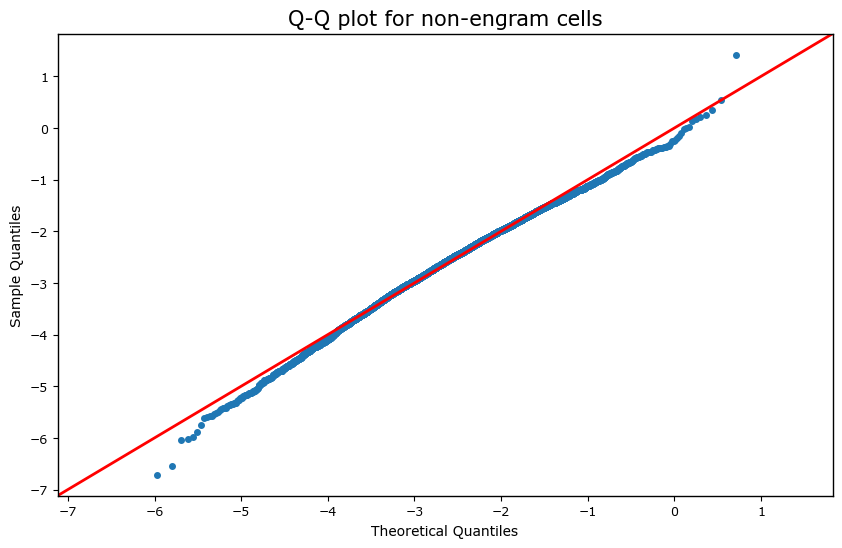

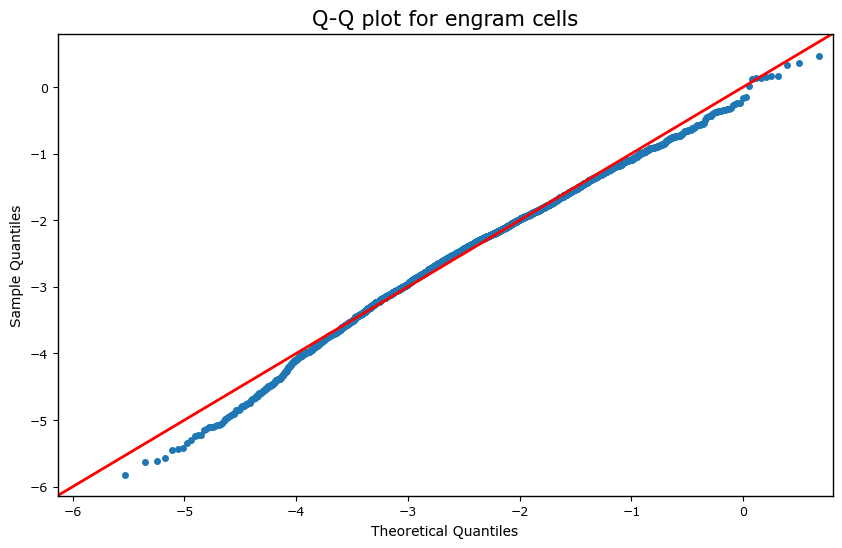

In [ ]:
# Evaluate if the new distributions i.e., the log-transformed versions are reasonably normal, first fit both to normal distributions

# Fit normal distribution to non-engram cells
non_engram_mu, non_engram_sigma = sp.stats.norm.fit(np.log(non_engram_cells['Event_Rate']))

# Fit normal distribution to engram cells
engram_mu, engram_sigma = sp.stats.norm.fit(np.log(engram_cells['Event_Rate']))

engram_normal = sp.stats.norm(engram_mu, engram_sigma)
non_engram_normal = sp.stats.norm(non_engram_mu, non_engram_sigma)

# plot a ks test for both
fig, ax = plt.subplots(figsize=(10, 6))
sm.qqplot(np.log(non_engram_cells['Event_Rate']), dist=non_engram_normal, line='45', ax=ax)
ax.set_title('Q-Q plot for non-engram cells')

fig, ax = plt.subplots(figsize=(10, 6))
sm.qqplot(np.log(engram_cells['Event_Rate']), dist=engram_normal, line='45', ax=ax)
ax.set_title('Q-Q plot for engram cells')

## Figure 3A Stats
 Linear Mixed Effects Model (Population X Session) all animals

In [ ]:
# label all categoricals as such
data['Animal'] = data['Animal'].astype('category')
data['Session'] = data['Session'].astype('category')
data['Population'] = data['Population'].astype('category')


In [ ]:
model = sm.MixedLM.from_formula("np.log1p(Event_Rate)~C(Population)*C(Session)", 
                                data, groups=data["Animal"]).fit()
model.summary()

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                       Mixed Linear Model Regression Results
===================================================================================
Model:                   MixedLM      Dependent Variable:      np.log1p(Event_Rate)
No. Observations:        9551         Method:                  REML                
No. Groups:              16           Scale:                   0.0080              
Min. group size:         193          Log-Likelihood:          9443.1429           
Max. group size:         921          Converged:               Yes                 
Mean group size:         596.9                                                     
-----------------------------------------------------------------------------------
                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                 0.096    0.007 14.763 0.000  0.083  0.109
C(Population)[T.Tagged]                   0.017    0.003  5.919 0.000  0.011  0.022
C(Session)[T.D4]                         -0.003    0.002 -1.346 0.178 -0.007  0.001
C(Population)[T.Tagged]:C(Session)[T.D4]  0.001    0.004  0.309 0.758 -0.006  0.009
Group Var                                 0.001    0.003                           
===================================================================================

"""

In [ ]:
model.pvalues

Intercept                                   2.550429e-49
C(Population)[T.Tagged]                     3.232894e-09
C(Session)[T.D4]                            1.782861e-01
C(Population)[T.Tagged]:C(Session)[T.D4]    7.576515e-01
Group Var                                   7.596369e-03
dtype: float64

## FIGURE 3B 
 Linear Mixed Effects Model (Population X Session X Group) all animals

In [ ]:
data['Group'] = data['Group'].astype('category')
model = sm.MixedLM.from_formula("np.log1p(Event_Rate)~C(Population)*C(Session)*C(Group)", data, groups=data["Animal"]).fit()


/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                              Mixed Linear Model Regression Results
==================================================================================================
Model:                        MixedLM           Dependent Variable:           np.log1p(Event_Rate)
No. Observations:             9551              Method:                       REML                
No. Groups:                   16                Scale:                        0.0080              
Min. group size:              193               Log-Likelihood:               9442.6722           
Max. group size:              921               Converged:                    Yes                 
Mean group size:              596.9                                                               
--------------------------------------------------------------------------------------------------
                                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------------
Intercept                                                0.102    0.009 11.027 0.000  0.084  0.121
C(Population)[T.Tagged]                                  0.012    0.004  2.957 0.003  0.004  0.019
C(Session)[T.D4]                                         0.005    0.003  1.465 0.143 -0.002  0.011
C(Group)[T.HC]                                          -0.012    0.013 -0.927 0.354 -0.038  0.014
C(Population)[T.Tagged]:C(Session)[T.D4]                 0.006    0.005  1.187 0.235 -0.004  0.017
C(Population)[T.Tagged]:C(Group)[T.HC]                   0.010    0.006  1.819 0.069 -0.001  0.021
C(Session)[T.D4]:C(Group)[T.HC]                         -0.015    0.004 -3.453 0.001 -0.024 -0.007
C(Population)[T.Tagged]:C(Session)[T.D4]:C(Group)[T.HC] -0.011    0.008 -1.427 0.154 -0.026  0.004
Group Var                                                0.001    0.003                           
==================================================================================================

"""

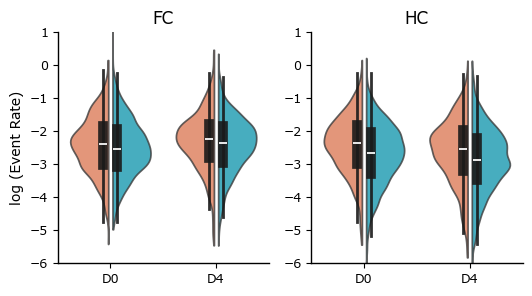

In [ ]:
hue_order = ['Tagged','Non-Tagged']
order = ['FC','HC']
fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(6,3))
sb.violinplot(data=data.loc[data['Group']=='FC'],y='logEventRate',x='Session',hue='Population',dodge=.5,width=.8,bw_adjust=.9,cut=0,
              gap=0.1,density_norm='width',split=True,hue_order=hue_order,alpha=0.8,inner='box',palette=['#F37243','#00ABC8'],ax=ax[0],inner_kws=dict(box_width=7, whis_width=2, color="0.1",alpha=0.9))

sb.violinplot(data=data.loc[data['Group']=='HC'],y='logEventRate',x='Session',hue='Population',dodge=.5,width=.8,bw_adjust=.9,cut=0,
              gap=0.1,density_norm='width',split=True,hue_order=hue_order,alpha=0.8,inner='box',palette=['#F37243','#00ABC8'],ax=ax[1],inner_kws=dict(box_width=7, whis_width=2, color="0.1",alpha=0.9))
plt.setp(ax,ylim=(-6,1))
titles=['FC','HC']
for a,axis in enumerate(ax):
    despine(axis)
    axis.legend().remove()
    axis.set_title(titles[a],size=12)
ax[0].set_ylabel('log (Event Rate)')
ax[1].set_ylabel('')
ax[0].set_xlabel('')
ax[1].set_xlabel('')

plt.savefig(f"Violinplots_LME_allcells_totaltime.svg",transparent=True)

## Figure 3C -
Rest Linear Mixed Effects Model (logRate ~ Population x Session x Group)

In [ ]:
rest_data['logEventRate']=np.log(rest_data['Event_Rate'])
rest_data['Animal'] = rest_data['Animal'].astype('category')
rest_data['Session'] = rest_data['Session'].astype('category')
rest_data['Population'] = rest_data['Population'].astype('category')
rest_data['Group'] = rest_data['Group'].astype('category')
rest_model = sm.MixedLM.from_formula("np.log1p(Event_Rate)~C(Population)*C(Session)*C(Group)", rest_data, groups=rest_data["Animal"]).fit()

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
rest_model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                              Mixed Linear Model Regression Results
==================================================================================================
Model:                        MixedLM           Dependent Variable:           np.log1p(Event_Rate)
No. Observations:             8158              Method:                       REML                
No. Groups:                   13                Scale:                        0.0079              
Min. group size:              193               Log-Likelihood:               8137.0354           
Max. group size:              921               Converged:                    Yes                 
Mean group size:              627.5                                                               
--------------------------------------------------------------------------------------------------
                                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------------
Intercept                                                0.079    0.006 14.231 0.000  0.068  0.090
C(Population)[T.Tagged]                                  0.012    0.004  2.868 0.004  0.004  0.020
C(Session)[T.D4]                                        -0.007    0.003 -2.299 0.021 -0.014 -0.001
C(Group)[T.HC]                                          -0.010    0.008 -1.291 0.197 -0.026  0.005
C(Population)[T.Tagged]:C(Session)[T.D4]                 0.002    0.006  0.413 0.680 -0.009  0.013
C(Population)[T.Tagged]:C(Group)[T.HC]                   0.007    0.006  1.116 0.265 -0.005  0.019
C(Session)[T.D4]:C(Group)[T.HC]                          0.001    0.005  0.166 0.868 -0.009  0.010
C(Population)[T.Tagged]:C(Session)[T.D4]:C(Group)[T.HC] -0.008    0.009 -0.955 0.340 -0.025  0.009
Group Var                                                0.000    0.001                           
==================================================================================================

"""

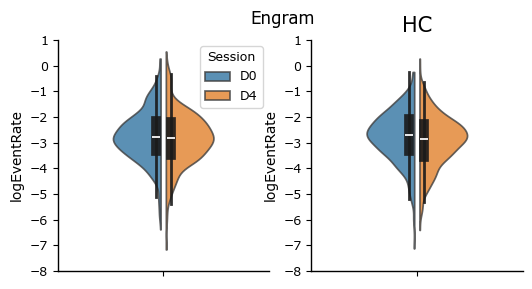

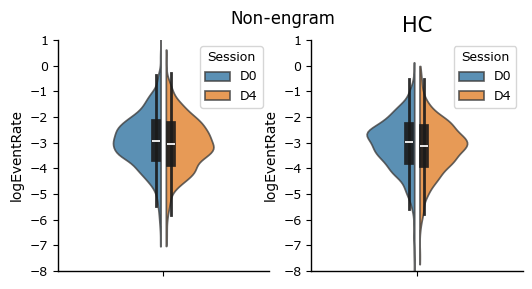

In [ ]:
hue_order = ['Tagged','Non-Tagged']
fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(6,3))
sb.violinplot(data=rest_data.loc[(rest_data['Population']=='Tagged')&(rest_data['Group']=='FC')],y='logEventRate',hue='Session',dodge=.5,width=.5,bw_adjust=.9,cut=0,
              gap=0.1,density_norm='width',split=True,alpha=0.8,inner='box',ax=ax[0],inner_kws=dict(box_width=7, whis_width=2, color="0.1",alpha=0.9))
plt.title('FC')
sb.violinplot(data=rest_data.loc[(rest_data['Population']=='Tagged')&(rest_data['Group']=='HC')],y='logEventRate',hue='Session',dodge=.5,width=.5,bw_adjust=.9,cut=0,
              gap=0.1,density_norm='width',split=True,alpha=0.8,inner='box',ax=ax[1],inner_kws=dict(box_width=7, whis_width=2, color="0.1",alpha=0.9))
plt.title('HC')
plt.setp(ax, ylim=[-8,1])
plt.gca().legend_.remove()
plt.suptitle('Engram')
sb.despine()

fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(6,3))
sb.violinplot(data=rest_data.loc[(rest_data['Population']=='Non-Tagged')&(rest_data['Group']=='FC')],y='logEventRate',hue='Session',dodge=.5,width=.5,bw_adjust=.9,cut=0,
              gap=0.1,density_norm='width',split=True,alpha=0.8,inner='box',ax=ax[0],inner_kws=dict(box_width=7, whis_width=2, color="0.1",alpha=0.9))
plt.title('FC')
sb.violinplot(data=rest_data.loc[(rest_data['Population']=='Non-Tagged')&(rest_data['Group']=='HC')],y='logEventRate',hue='Session',dodge=.5,width=.5,bw_adjust=.9,cut=0,
              gap=0.1,density_norm='width',split=True,alpha=0.8,inner='box',ax=ax[1],inner_kws=dict(box_width=7, whis_width=2, color="0.1",alpha=0.9))
plt.title('HC')

plt.suptitle('Non-engram')
plt.setp(ax, ylim=[-8,1])
sb.despine()
#plt.savefig('Violinplots_GroupLME_rest.svg')

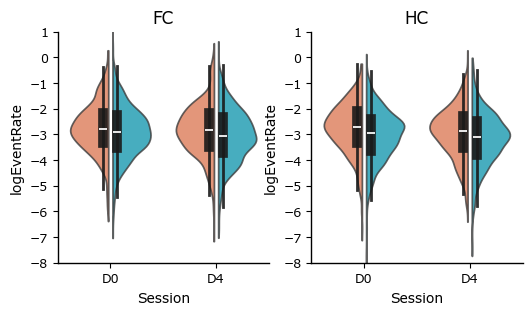

In [ ]:
hue_order = ['Tagged','Non-Tagged']
fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(6,3))
sb.violinplot(data=rest_data.loc[rest_data['Group']=='FC'],y='logEventRate',x='Session',hue='Population',dodge=.5,width=.8,bw_adjust=.9,cut=0,
              gap=0.1,density_norm='width',split=True,hue_order=hue_order,alpha=0.8,inner='box',palette=['#F37243','#00ABC8'],ax=ax[0],inner_kws=dict(box_width=7, whis_width=2, color="0.1",alpha=0.9))
sb.violinplot(data=rest_data.loc[rest_data['Group']=='HC'],y='logEventRate',x='Session',hue='Population',dodge=.5,width=.8,bw_adjust=.9,cut=0,
              gap=0.1,density_norm='width',split=True,hue_order=hue_order,alpha=0.8,inner='box',palette=['#F37243','#00ABC8'],ax=ax[1],inner_kws=dict(box_width=7, whis_width=2, color="0.1",alpha=0.9))
plt.setp(ax, ylim=[-8,1])
sb.despine()
plt.gca().legend_.remove()
titles=['FC','HC']
for a,axis in enumerate(ax):
    despine(axis)
    axis.legend().remove()
    axis.set_title(titles[a],size=12)
plt.savefig('Fig3B_Violinplots_GroupLME_rest.svg',transparent=True)

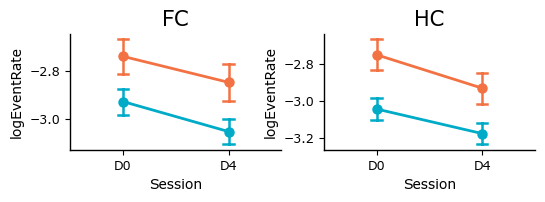

In [ ]:
hue_order = ['Tagged','Non-Tagged']
fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(6,1.5))
sb.pointplot(data=rest_data.loc[(rest_data['Group']=='FC')],
             y='logEventRate',hue='Population',x='Session',
             ax=ax[0],
             hue_order=hue_order,
             errorbar='ci',
             palette=['#F37243','#00ABC8'],
             capsize=0.1,
             markers='o',
             linestyles='-',
             dodge=0,
             markersize=6,
             linewidth=2,
             err_kws=dict(lw=1.8))
ax[0].set_title('FC')
sb.pointplot(data=rest_data.loc[(rest_data['Group']=='HC')],
             y='logEventRate',
             hue='Population',x='Session' ,
             ax=ax[1],
             hue_order=hue_order,
             errorbar='ci',
             palette=['#F37243','#00ABC8'],
             capsize=0.1,
             markers='o',
             linestyles='-',
             dodge=0,
             markersize=6,
             linewidth=2,
             err_kws=dict(lw=1.8))
ax[1].set_title('HC')
ax[0].legend_.remove()
ax[1].legend_.remove()

sb.despine()
plt.savefig('Fig3B_pointplot_rest_95ci.svg',transparent=True)

In [ ]:
reg_rest = rest_data.loc[(rest_data['Baseline']!=-1)&(rest_data['Post']!=-1)]

In [ ]:
df = reg_rest.loc[reg_rest['Session']=='D0', ['Population', 'Session', 'Animal', 'FOV', 'Group','Event_Rate']].copy().rename(columns={'Event_Rate':'Event_Rate_D0'})
df['Event_Rate_D4']=reg_rest['Event_Rate'].loc[reg_rest['Session']=='D4'].values
df

,Population,Session,Animal,FOV,Group,Event_Rate_D0,Event_Rate_D4
0,Non-Tagged,D0,989N,FOV1,FC,0.057010,0.035292
1,Non-Tagged,D0,989N,FOV1,FC,0.105843,0.075981
2,Non-Tagged,D0,989N,FOV1,FC,0.101168,0.047637
3,Non-Tagged,D0,989N,FOV1,FC,0.043712,0.039422
4,Non-Tagged,D0,989N,FOV1,FC,0.060200,0.027747
...,...,...,...,...,...,...,...
7937,Non-Tagged,D0,1912L,FOV2,HC,0.009934,0.037597
7938,Non-Tagged,D0,1912L,FOV2,HC,0.056367,0.053295
7939,Tagged,D0,1912L,FOV2,HC,0.051972,0.057360
7940,Non-Tagged,D0,1912L,FOV2,HC,0.002193,0.016463


## Figure 3D 
Linear Mixed Effects Model (logRate ~ Population x Session x Group)

In [ ]:
run_data['logEventRate']=np.log(run_data['Event_Rate'])
run_data['Animal'] = run_data['Animal'].astype('category')
run_data['Session'] = run_data['Session'].astype('category')
run_data['Population'] = run_data['Population'].astype('category')
run_data['Group'] = run_data['Group'].astype('category')
run_model = sm.MixedLM.from_formula("np.log1p(Event_Rate)~C(Population)*C(Session)*C(Group)", run_data, groups=run_data["Animal"]).fit()

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
run_model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                              Mixed Linear Model Regression Results
==================================================================================================
Model:                        MixedLM           Dependent Variable:           np.log1p(Event_Rate)
No. Observations:             8158              Method:                       REML                
No. Groups:                   13                Scale:                        0.0370              
Min. group size:              193               Log-Likelihood:               1823.3538           
Max. group size:              921               Converged:                    Yes                 
Mean group size:              627.5                                                               
--------------------------------------------------------------------------------------------------
                                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------------
Intercept                                                0.177    0.026  6.724 0.000  0.125  0.229
C(Population)[T.Tagged]                                  0.011    0.009  1.228 0.219 -0.006  0.028
C(Session)[T.D4]                                         0.001    0.007  0.071 0.943 -0.013  0.014
C(Group)[T.HC]                                          -0.044    0.039 -1.136 0.256 -0.120  0.032
C(Population)[T.Tagged]:C(Session)[T.D4]                 0.008    0.012  0.622 0.534 -0.016  0.032
C(Population)[T.Tagged]:C(Group)[T.HC]                   0.017    0.013  1.267 0.205 -0.009  0.043
C(Session)[T.D4]:C(Group)[T.HC]                         -0.012    0.010 -1.156 0.248 -0.032  0.008
C(Population)[T.Tagged]:C(Session)[T.D4]:C(Group)[T.HC] -0.021    0.018 -1.113 0.266 -0.057  0.016
Group Var                                                0.005    0.011                           
==================================================================================================

"""

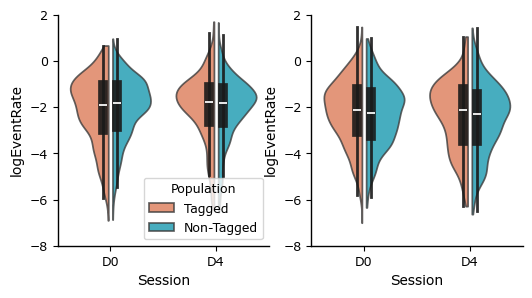

In [ ]:
hue_order = ['Tagged','Non-Tagged']
fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(6,3))
sb.violinplot(data=run_data.loc[run_data['Group']=='FC'],y='logEventRate',x='Session',hue='Population',dodge=.5,width=.8,bw_adjust=.9,cut=0,
              gap=0.1,density_norm='width',split=True,hue_order=hue_order,alpha=0.8,inner='box',palette=['#F37243','#00ABC8'],ax=ax[0],inner_kws=dict(box_width=7, whis_width=2, color="0.1",alpha=0.9))
sb.violinplot(data=run_data.loc[run_data['Group']=='HC'],y='logEventRate',x='Session',hue='Population',dodge=.5,width=.8,bw_adjust=.9,cut=0,
              gap=0.1,density_norm='width',split=True,hue_order=hue_order,alpha=0.8,inner='box',palette=['#F37243','#00ABC8'],ax=ax[1],inner_kws=dict(box_width=7, whis_width=2, color="0.1",alpha=0.9))
plt.setp(ax, ylim=[-8,2])
sb.despine()
plt.gca().legend_.remove()
plt.savefig('Fig3C_Violinplots_GroupLME_run.svg',transparent=True)

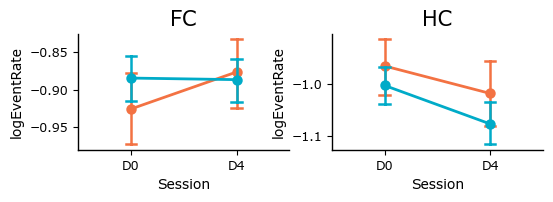

In [ ]:
hue_order = ['Tagged','Non-Tagged']
fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(6,1.5))
sb.pointplot(data=run_data.loc[(run_data['Group']=='FC')],y='logEventRate',
             hue='Population',x='Session',ax=ax[0],
             hue_order=hue_order,errorbar='ci',palette=['#F37243','#00ABC8'],
             capsize=0.1,
             markers='o',
             linestyles='-',
             dodge=0,
             markersize=6,
             linewidth=2,
             err_kws=dict(lw=1.8))
ax[0].set_title('FC')
sb.pointplot(data=run_data.loc[(run_data['Group']=='HC')],y='logEventRate',
             hue='Population',x='Session',ax=ax[1],
             hue_order=hue_order,
             errorbar='ci',palette=['#F37243','#00ABC8'],
             capsize=0.1,
             markers='o',
             linestyles='-',
             dodge=0,
             markersize=6,
             linewidth=2,
             err_kws=dict(lw=1.8))
ax[1].set_title('HC')
ax[0].legend_.remove()
ax[1].legend_.remove()

sb.despine()
plt.savefig('Fig3C_pointplot_run_95ci.svg',transparent=True)

In [ ]:
reg_run = run_data.loc[(run_data['Baseline']!=-1)&(run_data['Post']!=-1)]

# Compare D4 HC vs FC

In [ ]:
colors_group = ['dodgerblue','peru']

rest_d4 = rest_data.loc[rest_data['Session']=='D4'].copy()
rest_d4.replace([np.inf, -np.inf], np.nan, inplace=True)
rest_d4.dropna(inplace=True)
run_d4 = run_data.loc[run_data['Session']=='D4'].copy()
run_d4.replace([np.inf, -np.inf], np.nan, inplace=True)
run_d4.dropna(inplace=True)


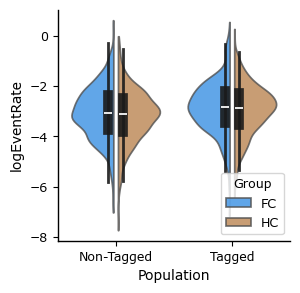

In [ ]:
hue_order = ['Tagged','Non-Tagged']
fig,ax=plt.subplots(ncols=1,nrows=1,figsize=(3,3))
sb.violinplot(data=rest_d4,y='logEventRate',hue='Group',x='Population',dodge=.5,width=.8,bw_adjust=.9,cut=0,legend=True,
              gap=0.1,density_norm='width',split=True,alpha=0.8,inner='box',palette=colors_group,ax=ax,inner_kws=dict(box_width=7, whis_width=2, color="0.1",alpha=0.9))
# sb.violinplot(data=run_d4,y='logEventRate',hue='Group',x='Population',dodge=.5,width=.8,bw_adjust=.9,cut=0,legend=True,
#               gap=0.1,density_norm='width',split=True,alpha=0.8,inner='box',palette=colors_group,ax=ax[1],inner_kws=dict(box_width=7, whis_width=2, color="0.1",alpha=0.9))
# plt.setp(ax, ylim=[-8,2])
sb.despine()
plt.savefig('Violinplots_D4_group_hue.png',transparent=True)

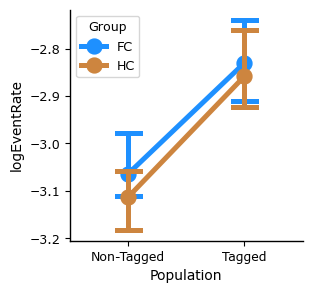

In [ ]:
fig,ax=plt.subplots(ncols=1,nrows=1,figsize=(3,3))
sb.pointplot(data=rest_d4,y='logEventRate',hue='Group',x='Population',estimator=np.median,ax=ax,errorbar='ci',palette=colors_group,capsize=.2)


sb.despine()


In [ ]:
import pingouin as pg

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [ ]:
pg.normality(data=rest_d4, dv='logEventRate',group='Group')

,W,pval,normal
Group,,,
FC,0.995210,1.198397e-06,False
HC,0.992514,5.333656e-08,False


In [ ]:
fc_tag_d4=rest_d4['logEventRate'].loc[(rest_d4['Group']=='FC')&(rest_d4['Population']=='Tagged')].values
fc_non_d4=rest_d4['logEventRate'].loc[(rest_d4['Group']=='FC')&(rest_d4['Population']=='Non-Tagged')].values
hc_tag_d4=rest_d4['logEventRate'].loc[(rest_d4['Group']=='HC')&(rest_d4['Population']=='Tagged')].values
hc_non_d4=rest_d4['logEventRate'].loc[(rest_d4['Group']=='HC')&(rest_d4['Population']=='Non-Tagged')].values

In [ ]:
rest_d4 = rest_data.loc[rest_data['Session']=='D4'].copy()
rest_d4.replace([np.inf, -np.inf], np.nan, inplace=True)
rest_d4.dropna(inplace=True)
rest_d4['Animal'] = rest_d4['Animal'].astype('category')
rest_d4['Population'] = rest_d4['Population'].astype('category')
rest_d4['Group'] = rest_d4['Group'].astype('category')
rest_d4_lmm= sm.MixedLM.from_formula("(logEventRate)~C(Population)*C(Group)", rest_d4, groups=rest_d4["Animal"]).fit()
rest_d4_lmm.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                      Mixed Linear Model Regression Results
==================================================================================
Model:                    MixedLM         Dependent Variable:         logEventRate
No. Observations:         4073            Method:                     REML        
No. Groups:               13              Scale:                      1.0535      
Min. group size:          85              Log-Likelihood:             -5908.9436  
Max. group size:          496             Converged:                  Yes         
Mean group size:          313.3                                                   
----------------------------------------------------------------------------------
                                       Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                              -3.095    0.098 -31.522 0.000 -3.287 -2.902
C(Population)[T.Tagged]                 0.234    0.047   5.019 0.000  0.143  0.326
C(Group)[T.HC]                         -0.118    0.144  -0.817 0.414 -0.400  0.165
C(Population)[T.Tagged]:C(Group)[T.HC] -0.057    0.071  -0.808 0.419 -0.197  0.082
Group Var                               0.061    0.027                            
==================================================================================

"""

In [ ]:
rest_d4_lmm.pvalues

Intercept                                 4.316324e-218
C(Population)[T.Tagged]                    5.192310e-07
C(Group)[T.HC]                             4.140103e-01
C(Population)[T.Tagged]:C(Group)[T.HC]     4.190774e-01
Group Var                                  2.828312e-02
dtype: float64

In [ ]:
run_data.head()

,Unnamed: 0,Baseline,Post,Population,Event_Rate,Session,Animal,FOV,Group,logEventRate
0,0,0,0,Non-Tagged,0.000000,D0,989N,FOV1,FC,-inf
1,1,8,18,Non-Tagged,0.104775,D0,989N,FOV1,FC,-2.255942
2,2,12,10,Non-Tagged,0.103226,D0,989N,FOV1,FC,-2.270832
3,3,14,11,Non-Tagged,0.000000,D0,989N,FOV1,FC,-inf
4,4,15,12,Non-Tagged,0.124128,D0,989N,FOV1,FC,-2.086442


In [ ]:
run_data['logEventRate']=np.log10(run_data['Event_Rate'])

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
run_d4 = run_data.loc[run_data['Session']=='D4'].copy()
run_d4.replace([np.inf, -np.inf], np.nan, inplace=True)
run_d4.dropna(inplace=True)
run_d4['Animal'] = run_d4['Animal'].astype('category')
run_d4['Population'] = run_d4['Population'].astype('category')
run_d4['Group'] = run_d4['Group'].astype('category')
run_d4_lmm= sm.MixedLM.from_formula("logEventRate~C(Population)*C(Group)", run_d4, groups=run_d4["Animal"]).fit()
run_d4_lmm.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
                      Mixed Linear Model Regression Results
==================================================================================
Model:                    MixedLM         Dependent Variable:         logEventRate
No. Observations:         3407            Method:                     REML        
No. Groups:               13              Scale:                      0.3509      
Min. group size:          42              Log-Likelihood:             -3078.1659  
Max. group size:          499             Converged:                  Yes         
Mean group size:          262.1                                                   
----------------------------------------------------------------------------------
                                       Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                              -0.896    0.080 -11.241 0.000 -1.052 -0.740
C(Population)[T.Tagged]                 0.023    0.029   0.792 0.429 -0.034  0.079
C(Group)[T.HC]                         -0.166    0.117  -1.416 0.157 -0.395  0.064
C(Population)[T.Tagged]:C(Group)[T.HC]  0.022    0.046   0.485 0.627 -0.067  0.112
Group Var                               0.042    0.032                            
==================================================================================

"""